# Avito AntiBot

Классификация cookies по событиям внутри 24-часового окна.




## 1. Установка



In [31]:
%pip install -q lightgbm==4.7.0 xgboost==3.4.1


## 2. Импорт библиотек



In [32]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


## 3. Загрузка данных

Загрузите в `/content` исходные файлы `train.csv`, `test.csv`, `events.csv.gz` и матрицы XGBoost `top150_train.csv.gz`, `top150_test.csv.gz`. Последние два файла содержат 150 подготовленных признаков

In [33]:
import os

print(os.listdir("/content"))

['.config', 'metric.py', 'submission.csv', '.ipynb_checkpoints', 'content', 'sample_data']


In [34]:
DATA_DIR = "/content/content"

date_columns = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=date_columns)
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=date_columns)
events = pd.read_csv(f"{DATA_DIR}/events.csv.gz", parse_dates=["event_ts"])
xgb_train_raw = pd.read_csv(f"{DATA_DIR}/top150_train.csv.gz", float_precision="round_trip")
xgb_test_raw = pd.read_csv(f"{DATA_DIR}/top150_test.csv.gz", float_precision="round_trip")

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)
print("XGBoost Top-150:", xgb_train_raw.shape, xgb_test_raw.shape)
print("bot rate:", round(train["target"].mean(), 4))


train: (11091, 5)
test: (4909, 4)
events: (328905, 14)
XGBoost Top-150: (11091, 153) (4909, 152)
bot rate: 0.0811


### Первичный осмотр

Проверяем распределение целевой переменной, типов событий и платформ. Этот блок только отображает исходные данные.


In [35]:
summary = pd.DataFrame(
    {
        "train": [
            len(train),
            train.window_start_ts.min(),
            train.window_start_ts.max(),
            int(train.target.sum()),
            train.target.mean(),
        ],
        "test": [
            len(test),
            test.window_start_ts.min(),
            test.window_start_ts.max(),
            None,
            None,
        ],
    },
    index=["cookies", "first window", "last window", "bot cookies", "bot rate"],
)
summary


,train,test
cookies,11091,4909
first window,2026-04-06 00:00:00,2026-04-20 00:00:00
last window,2026-04-19 00:00:00,2026-04-26 00:00:00
bot cookies,899,None
bot rate,0.081057,None


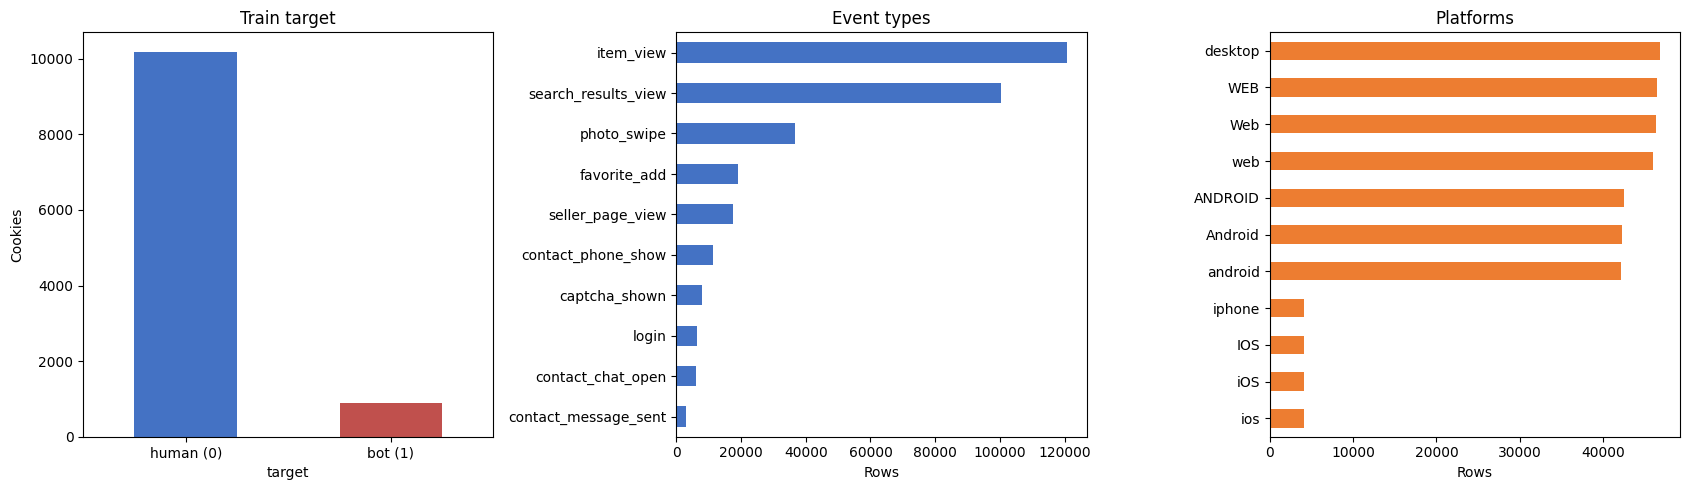

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

train.target.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4472C4", "#C0504D"]
)
axes[0].set_title("Train target")
axes[0].set_xticklabels(["human (0)", "bot (1)"], rotation=0)
axes[0].set_ylabel("Cookies")

events.event_name.value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="#4472C4"
)
axes[1].set_title("Event types")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("")

events.platform.fillna("<missing>").value_counts().sort_values().plot(
    kind="barh", ax=axes[2], color="#ED7D31"
)
axes[2].set_title("Platforms")
axes[2].set_xlabel("Rows")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


Train охватывает 6–19 апреля, test — следующие 7 дней. Валидация проводится на окнах с 17 апреля, случайного разбиения нет.

## 4. Метрика

Cookies ранжируются по score. Одинаковые значения score обрабатываются одной группой. Итог — максимальный precision среди порогов, у которых recall не ниже 0.70.


In [37]:
TARGET_RECALL = 0.70


def precision_at_recall(y_true, score, recall=TARGET_RECALL):
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    order = np.argsort(-score, kind="mergesort")
    y = y_true[order]
    sorted_score = score[order]

    positive_count = y.sum()
    if positive_count == 0:
        return float("nan")

    true_positives = np.cumsum(y)
    selected = np.arange(1, len(y) + 1)
    group_ends = np.r_[sorted_score[1:] != sorted_score[:-1], True]
    precision = true_positives[group_ends] / selected[group_ends]
    recall_values = true_positives[group_ends] / positive_count
    eligible = recall_values >= recall
    return float(precision[eligible].max()) if eligible.any() else 0.0


## 5. Конфигурация моделей

Параметры LightGBM, XGBoost, seeds и веса ансамбля зафиксированы.


In [38]:
SEEDS = [0, 1, 7, 42, 123, 11, 29, 73, 2026, 3407]

EVENT_TYPES = sorted(
    [
        "contact_chat_open",
        "contact_message_sent",
        "contact_phone_show",
        "favorite_add",
        "item_view",
        "login",
        "photo_swipe",
        "search_results_view",
        "seller_page_view",
    ]
)

BASE_PARAMS = dict(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    n_jobs=4,
    verbosity=-1,
)

POINTER_PARAMS = dict(
    objective="binary",
    colsample_bytree=0.94500090035736,
    extra_trees=False,
    learning_rate=0.027749622019760254,
    max_bin=255,
    max_depth=4,
    min_child_samples=20,
    min_split_gain=0.35989052708910574,
    n_estimators=1000,
    num_leaves=10,
    path_smooth=0.9087876737984324,
    reg_alpha=0.005269080909714222,
    reg_lambda=0.4508762463821835,
    scale_pos_weight=0.7421219676315555,
    subsample=0.98096822550102,
    subsample_freq=1,
    n_jobs=4,
    verbosity=-1,
)

POINTER_COLUMNS = [
    "ptr_x_mean", "ptr_x_std", "ptr_x_q25", "ptr_x_median", "ptr_x_q75", "ptr_x_max",
    "ptr_y_mean", "ptr_y_std", "ptr_y_q25", "ptr_y_median", "ptr_y_q75", "ptr_y_max",
    "ptr_radius_mean", "ptr_radius_std", "ptr_radius_q25", "ptr_radius_median",
    "ptr_radius_q75", "ptr_radius_max", "ptr_anisotropy", "ptr_area",
    "ptr_motion_mean", "ptr_motion_std", "ptr_motion_q25", "ptr_motion_median",
    "ptr_motion_q75", "ptr_motion_max", "ptr_speed_mean", "ptr_speed_std",
    "ptr_speed_q25", "ptr_speed_median", "ptr_speed_q75", "ptr_speed_max",
    "ptr_stationary", "ptr_axis_aligned", "ptr_straightness", "ptr_turn_cos_mean",
    "ptr_turn_cos_std", "ptr_turn_cos_q25", "ptr_turn_cos_median",
    "ptr_turn_cos_q75", "ptr_turn_cos_max",
]

XGB_PARAMS = {
    "n_estimators": 1100,
    "max_depth": 3,
    "learning_rate": 0.021021350642334975,
    "min_child_weight": 3.1537755471735567,
    "subsample": 0.8299725030953123,
    "colsample_bytree": 0.971252034405246,
    "reg_alpha": 0.001508165186917903,
    "reg_lambda": 5.26418379907252,
    "gamma": 0.25087570716700136,
    "scale_pos_weight": 0.9781349158028367,
    "objective": "binary:logistic",
    "tree_method": "hist",
    "n_jobs": 3,
}

MODEL_WEIGHTS = {"safe": 0.40, "pointer": 0.40, "xgb": 0.20}


## 6. Генерация признаков

Все поведенческие признаки рассчитываются внутри 24-часового окна cookie. Матрица SAFE содержит исходный набор признаков; Pointer добавляет 41 признак траектории указателя.

### Общие функции и обработка событий


In [39]:
def normalize_platform_source(x):
    if pd.isna(x):
        return "unknown"

    x = str(x).strip().lower()


    if x in {"web", "desktop"}:
        return "web"

    if x == "android":
        return "android"

    if x in {"ios", "iphone"}:
        return "ios"

    return x

def enrich_event_level(ev):
    out = ev.copy()

    out["platform_source"] = (
        out["platform"]
        .map(normalize_platform_source)
    )

    ua = (
        out["user_agent"]
        .fillna("")
        .astype(str)
    )

    ua_lower = ua.str.lower()

    out["ua_is_headless"] = (
        ua_lower
        .str.contains(
            "headlesschrome",
            regex=False,
        )
        .astype("int8")
    )

    out["ua_is_script"] = ua_lower.str.contains(
        "scrapy/|curl/|python-urllib|python-requests|node-fetch|go-http-client",
        regex=True,
    ).astype("int8")

    out["ua_is_avito_app"] = (
        ua.str.startswith("Avito/")
        .astype("int8")
    )

    out["ua_is_mobile"] = (
        ua_lower.str.contains("mobile", regex=False)
        | ua_lower.str.contains("android", regex=False)
        | ua_lower.str.contains("iphone", regex=False)
    ).astype("int8")

    out["ua_family"] = np.select(
        [
            out["ua_is_script"].astype(bool),
            out["ua_is_headless"].astype(bool),
            ua_lower.str.contains("yabrowser", regex=False),
            ua_lower.str.contains("firefox", regex=False),
            out["ua_is_avito_app"].astype(bool),
            ua_lower.str.contains("chrome", regex=False),
            ua_lower.str.contains("safari", regex=False),
        ],
        [
            "script",
            "headless",
            "yabrowser",
            "firefox",
            "avito_app",
            "chrome",
            "safari",
        ],
        default="other",
    )

    version = (
        ua.str.extract(r"HeadlessChrome/(\d+)", expand=False)
        .combine_first(
            ua.str.extract(r"YaBrowser/(\d+)", expand=False)
        )
        .combine_first(
            ua.str.extract(r"Firefox/(\d+)", expand=False)
        )
        .combine_first(
            ua.str.extract(r"Chrome/(\d+)", expand=False)
        )
        .combine_first(
            ua.str.extract(r"Avito/(\d+)", expand=False)
        )
        .combine_first(
            ua.str.extract(r"Version/(\d+)", expand=False)
        )
    )

    out["ua_major_version"] = pd.to_numeric(
        version,
        errors="coerce",
    )

    return out

PLATFORM_TYPES = [
    "web",
    "android",
    "ios",
    "unknown",
]

UA_FAMILIES = [
    "headless",
    "yabrowser",
    "firefox",
    "chrome",
    "safari",
    "avito_app",
    "script",
    "other",
]

def prepare_sequence_events(ev):
    return (
        ev.drop_duplicates()
        .sort_values(
            ["cookie_id", "event_ts"],
            kind="mergesort",
        )
        .copy()
    )

def safe_div(num, den):
    return num / den.replace(0, np.nan)

def entropy_from_counts(frame):
    arr = frame.to_numpy(dtype=float)
    row_sum = arr.sum(axis=1, keepdims=True)

    p = np.divide(
        arr,
        row_sum,
        out=np.zeros_like(arr),
        where=row_sum != 0,
    )

    logp = np.zeros_like(p)
    mask = p > 0
    logp[mask] = np.log(p[mask])

    return -(p * logp).sum(axis=1)


### Счётчики событий и разнообразие


In [40]:
def generate_source_basic_features(ev, meta, dup_stats):
    base = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)
    g = e.groupby("cookie_id", sort=False)

    base["n_events"] = g.size()

    base["item_nunique"] = g["item_id"].nunique()
    base["category_nunique"] = g["item_category"].nunique()
    base["location_nunique"] = g["item_location"].nunique()
    base["search_page_nunique"] = g["search_page"].nunique()

    item_views = (
        e["event_name"]
        .eq("item_view")
        .groupby(e["cookie_id"])
        .sum()
    )

    base["unique_items_per_item_event"] = safe_div(
        base["item_nunique"],
        item_views,
    )

    base["unique_categories_per_event"] = safe_div(
        base["category_nunique"],
        base["n_events"],
    )

    base["unique_locations_per_event"] = safe_div(
        base["location_nunique"],
        base["n_events"],
    )

    event_counts = pd.crosstab(
        e["cookie_id"],
        e["event_name"],
    )

    event_counts = event_counts.reindex(
        columns=EVENT_TYPES,
        fill_value=0,
    )

    for event_name in EVENT_TYPES:
        count = event_counts[event_name].reindex(base.index).fillna(0)

        base[f"event_ratio__{event_name}"] = safe_div(
            count,
            base["n_events"],
        )

    base["event_type_entropy"] = entropy_from_counts(
        event_counts.reindex(base.index).fillna(0)
    )

    search = e[
        e["event_name"].eq("search_results_view")
    ].copy()

    if len(search):
        sg = search.groupby("cookie_id")

        base["search_page_mean"] = sg["search_page"].mean()
        base["search_page_max"] = sg["search_page"].max()
        base["search_page_std"] = sg["search_page"].std()

        base["search_query_repeat_ratio"] = (
            1
            - safe_div(
                sg["search_query"].nunique(),
                sg["search_query"].count(),
            )
        )

    platform_counts = pd.crosstab(
        e["cookie_id"],
        e["platform_source"],
    )

    for platform in PLATFORM_TYPES:
        if platform not in platform_counts.columns:
            platform_counts[platform] = 0

        base[f"platform_ratio__{platform}"] = safe_div(
            platform_counts[platform].reindex(base.index).fillna(0),
            base["n_events"],
        )

    ua_counts = pd.crosstab(
        e["cookie_id"],
        e["ua_family"],
    )

    for family in UA_FAMILIES:
        if family not in ua_counts.columns:
            ua_counts[family] = 0

        base[f"ua_ratio__{family}"] = safe_div(
            ua_counts[family].reindex(base.index).fillna(0),
            base["n_events"],
        )

    base["pointer_present_ratio"] = (
        (
            e["pointer_x"].notna()
            & e["pointer_y"].notna()
        )
        .groupby(e["cookie_id"])
        .mean()
    )

    base["seller_type_present_ratio"] = (
        e["seller_type"]
        .notna()
        .groupby(e["cookie_id"])
        .mean()
    )

    ptr = e[
        e["pointer_x"].notna()
        & e["pointer_y"].notna()
    ].copy()

    if len(ptr):
        pg = ptr.groupby("cookie_id")

        base["pointer_count"] = pg.size()
        base["pointer_x_nunique"] = pg["pointer_x"].nunique()
        base["pointer_y_nunique"] = pg["pointer_y"].nunique()
        base["pointer_x_std"] = pg["pointer_x"].std()
        base["pointer_y_std"] = pg["pointer_y"].std()
        base["pointer_x_range"] = (
            pg["pointer_x"].max()
            - pg["pointer_x"].min()
        )
        base["pointer_y_range"] = (
            pg["pointer_y"].max()
            - pg["pointer_y"].min()
        )

        ptr["pointer_dx"] = (
            pg["pointer_x"].diff()
        )

        ptr["pointer_dy"] = (
            pg["pointer_y"].diff()
        )

        ptr["pointer_move"] = np.sqrt(
            ptr["pointer_dx"] ** 2
            + ptr["pointer_dy"] ** 2
        )

        move = (
            ptr.groupby("cookie_id")["pointer_move"]
            .agg(["mean", "median", "max"])
        )

        move.columns = [
            "pointer_move_mean",
            "pointer_move_median",
            "pointer_move_max",
        ]

        base = base.join(
            move,
            how="left",
        )


    e["prev_event_name"] = (
        e.groupby("cookie_id")["event_name"]
        .shift()
    )

    e["prev_event_ts"] = (
        e.groupby("cookie_id")["event_ts"]
        .shift()
    )

    valid_transition = (
        e["prev_event_name"].notna()
        & e["prev_event_ts"].notna()
        & (e["event_ts"] > e["prev_event_ts"])
    )

    trans = e.loc[
        valid_transition,
        [
            "cookie_id",
            "prev_event_name",
            "event_name",
        ],
    ].copy()

    trans["transition"] = (
        trans["prev_event_name"]
        + "__to__"
        + trans["event_name"]
    )

    if len(trans):
        counts = pd.crosstab(
            trans["cookie_id"],
            trans["transition"],
        )

        transition_total = (
            counts.sum(axis=1)
            .reindex(base.index)
        )

        base["transition_entropy"] = (
            entropy_from_counts(
                counts.reindex(base.index).fillna(0)
            )
        )

        for transition in counts.columns:
            base[
                f"transition_ratio__{transition}"
            ] = safe_div(
                counts[transition].reindex(base.index).fillna(0),
                transition_total,
            )


    dup = (
        dup_stats.set_index("cookie_id")[
            "exact_duplicate_rate"
        ]
    )

    base["duplicate_ratio"] = dup.reindex(base.index)

    meta_idx = meta.set_index("cookie_id")

    base["cookie_age_days"] = (
        (
            meta_idx["window_start_ts"]
            - meta_idx["cookie_created_at"]
        )
        .dt.total_seconds()
        / 86400
    )

    return (
        base.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )


### Временные характеристики и последовательности


In [41]:
def generate_source_temporal_features(ev, meta):
    temporal = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)

    g = e.groupby("cookie_id", sort=False)

    e["gap_sec"] = (
        g["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    gap = e[
        e["gap_sec"].notna()
    ].copy()

    gg = gap.groupby("cookie_id")

    temporal["gap_mean_sec"] = gg["gap_sec"].mean()
    temporal["gap_std_sec"] = gg["gap_sec"].std()
    temporal["gap_min_sec"] = gg["gap_sec"].min()
    temporal["gap_max_sec"] = gg["gap_sec"].max()
    temporal["gap_median_sec"] = gg["gap_sec"].median()

    for q in [0.10, 0.25, 0.75, 0.90]:
        temporal[
            f"gap_q{int(q * 100):02d}_sec"
        ] = gg["gap_sec"].quantile(q)

    for threshold in [1, 5, 10, 30, 60]:
        temporal[
            f"gap_share_lt_{threshold}s"
        ] = (
            gap["gap_sec"]
            .lt(threshold)
            .groupby(gap["cookie_id"])
            .mean()
        )

    for threshold in [300, 600, 1800]:
        temporal[
            f"gap_share_gt_{threshold}s"
        ] = (
            gap["gap_sec"]
            .gt(threshold)
            .groupby(gap["cookie_id"])
            .mean()
        )

    first_ts = g["event_ts"].min()
    last_ts = g["event_ts"].max()

    temporal["active_span_sec"] = (
        last_ts - first_ts
    ).dt.total_seconds()

    n_events = g.size()

    temporal["events_per_active_minute"] = (
        n_events
        / (
            temporal["active_span_sec"]
            / 60
        ).clip(lower=1)
    )

    e["event_hour"] = e["event_ts"].dt.hour
    e["event_minute"] = (
        e["event_ts"].dt.floor("min")
    )

    temporal["active_hour_nunique"] = (
        e.groupby("cookie_id")["event_hour"]
        .nunique()
    )

    temporal["active_minute_nunique"] = (
        e.groupby("cookie_id")["event_minute"]
        .nunique()
    )

    minute_counts = (
        e.groupby(
            ["cookie_id", "event_minute"]
        )
        .size()
    )

    minute_stats = (
        minute_counts
        .groupby(level=0)
        .agg(["max", "mean"])
    )

    minute_stats.columns = [
        "max_events_per_minute",
        "mean_events_per_active_minute",
    ]

    temporal = temporal.join(
        minute_stats,
        how="left",
    )


    e["new_session"] = (
        e["gap_sec"].isna()
        | e["gap_sec"].gt(1800)
    )

    e["session_id"] = (
        e.groupby("cookie_id")["new_session"]
        .cumsum()
    )

    session_sizes = (
        e.groupby(
            ["cookie_id", "session_id"]
        )
        .size()
    )

    session_stats = (
        session_sizes
        .groupby(level=0)
        .agg(["count", "mean", "max"])
    )

    session_stats.columns = [
        "session_count",
        "session_size_mean",
        "session_size_max",
    ]

    temporal = temporal.join(
        session_stats,
        how="left",
    )

    def gap_unique_ratio(x):
        x = x.dropna().round()

        if len(x) == 0:
            return np.nan

        return x.nunique() / len(x)

    def gap_mode_share(x):
        x = x.dropna().round()

        if len(x) == 0:
            return np.nan

        return (
            x.value_counts(
                normalize=True
            )
            .iloc[0]
        )

    temporal["gap_unique_ratio"] = (
        g["gap_sec"]
        .apply(gap_unique_ratio)
    )

    temporal["gap_mode_share"] = (
        g["gap_sec"]
        .apply(gap_mode_share)
    )

    gap_mean = g["gap_sec"].mean()
    gap_std = g["gap_sec"].std()

    temporal["gap_cv"] = (
        gap_std
        / gap_mean.replace(0, np.nan)
    )

    temporal["burstiness"] = (
        (gap_std - gap_mean)
        / (
            gap_std + gap_mean
        ).replace(0, np.nan)
    )

    e["prev_gap_sec"] = (
        e.groupby("cookie_id")["gap_sec"]
        .shift()
    )

    e["gap_change_abs"] = (
        e["gap_sec"]
        - e["prev_gap_sec"]
    ).abs()

    gap_change = (
        e.groupby("cookie_id")["gap_change_abs"]
    )

    temporal["gap_change_mean"] = (
        gap_change.mean()
    )

    temporal["gap_change_median"] = (
        gap_change.median()
    )

    e["fast_gap"] = (
        e["gap_sec"].lt(30)
    )

    prev_fast = (
        e.groupby("cookie_id")["fast_gap"]
        .shift()
        .fillna(False)
        .astype(bool)
    )

    e["fast_burst_start"] = (
        e["fast_gap"]
        & ~prev_fast
    )

    temporal["fast_burst_count"] = (
        e.groupby("cookie_id")[
            "fast_burst_start"
        ]
        .sum()
    )


    e["prev_event_name"] = (
        e.groupby("cookie_id")["event_name"]
        .shift()
    )

    e["prev_event_ts"] = (
        e.groupby("cookie_id")["event_ts"]
        .shift()
    )

    transition_valid = (
        e["prev_event_name"].notna()
        & e["prev_event_ts"].notna()
        & (e["event_ts"] > e["prev_event_ts"])
    )

    for prev_event, current_event in [
        ("search_results_view", "item_view"),
        ("search_results_view", "search_results_view"),
        ("item_view", "item_view"),
        ("item_view", "search_results_view"),
        ("item_view", "photo_swipe"),
        ("item_view", "seller_page_view"),
        ("seller_page_view", "item_view"),
    ]:
        mask = (
            transition_valid
            & e["prev_event_name"].eq(prev_event)
            & e["event_name"].eq(current_event)
            & e["gap_sec"].notna()
        )

        tr = e.loc[
            mask,
            ["cookie_id", "gap_sec"],
        ]

        if len(tr) == 0:
            continue

        tg = (
            tr.groupby("cookie_id")["gap_sec"]
        )

        prefix = (
            f"transition_gap__{prev_event}"
            f"__to__{current_event}"
        )

        temporal[f"{prefix}__mean"] = tg.mean()
        temporal[f"{prefix}__median"] = tg.median()
        temporal[f"{prefix}__q25"] = tg.quantile(0.25)
        temporal[f"{prefix}__q75"] = tg.quantile(0.75)

    return (
        temporal.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )


### User-agent, поисковое и браузерное поведение


In [42]:
def generate_source_ua_features(ev, meta):
    features = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)
    g = e.groupby("cookie_id", sort=False)

    features["ua_is_mobile_ratio"] = (
        g["ua_is_mobile"].mean()
    )

    features["ua_major_version_nunique"] = (
        g["ua_major_version"].nunique()
    )

    prev_ua = (
        g["user_agent"].shift()
    )

    prev_family = (
        g["ua_family"].shift()
    )

    e["ua_changed"] = (
        prev_ua.notna()
        & e["user_agent"].ne(prev_ua)
    )

    e["ua_family_changed"] = (
        prev_family.notna()
        & e["ua_family"].ne(prev_family)
    )

    n_events = g.size()

    transition_count = (
        n_events - 1
    ).clip(lower=1)

    features["ua_change_ratio"] = (
        e.groupby("cookie_id")[
            "ua_changed"
        ]
        .sum()
        / transition_count
    )

    features["ua_family_change_ratio"] = (
        e.groupby("cookie_id")[
            "ua_family_changed"
        ]
        .sum()
        / transition_count
    )

    return (
        features.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )

def generate_source_diversity_features(ev, meta):
    features = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)

    search = e[
        e["event_name"].eq(
            "search_results_view"
        )
    ].copy()

    page = search[
        search["search_page"].notna()
    ].copy()

    page["search_page"] = pd.to_numeric(
        page["search_page"],
        errors="coerce",
    )

    page = page[
        page["search_page"].notna()
    ]

    if len(page):
        features["page_ge5_share"] = (
            page["search_page"]
            .ge(5)
            .groupby(page["cookie_id"])
            .mean()
        )

    query_page = search[
        search["search_query"].notna()
        & search["search_page"].notna()
    ].copy()

    query_page["search_page"] = pd.to_numeric(
        query_page["search_page"],
        errors="coerce",
    )

    query_page = query_page[
        query_page["search_page"].notna()
    ]

    if len(query_page):
        per_query = (
            query_page
            .groupby(
                ["cookie_id", "search_query"]
            )["search_page"]
            .max()
        )

        features["mean_max_page_per_query"] = (
            per_query
            .groupby(level=0)
            .mean()
        )

    return (
        features.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )


### Сборка SAFE-признаков


In [43]:
def generate_source_behavior_features(ev, meta):
    features = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)

    item_actions = e[
        e["item_id"].notna()
    ]

    if len(item_actions):
        actions_per_item = (
            item_actions
            .groupby(
                ["cookie_id", "item_id"]
            )
            .size()
        )

        features["mean_actions_per_item"] = (
            actions_per_item
            .groupby(level=0)
            .mean()
        )

    return (
        features.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )

def generate_source_pointer_features(ev, meta):
    features = pd.DataFrame(
        index=pd.Index(
            meta["cookie_id"],
            name="cookie_id",
        )
    )

    e = prepare_sequence_events(ev)

    ptr = e[
        e["pointer_x"].notna()
        & e["pointer_y"].notna()
    ].copy()

    if len(ptr) == 0:
        return features.reset_index()

    pg = ptr.groupby("cookie_id")

    ptr["pointer_position"] = list(
        zip(
            ptr["pointer_x"],
            ptr["pointer_y"],
        )
    )

    position_count = pg.size()

    position_nunique = (
        ptr.groupby("cookie_id")[
            "pointer_position"
        ]
        .nunique()
    )

    features["pointer_position_unique_ratio"] = safe_div(
        position_nunique,
        position_count,
    )

    position_counts = (
        ptr.groupby(
            [
                "cookie_id",
                "pointer_x",
                "pointer_y",
            ]
        )
        .size()
    )

    top1_count = (
        position_counts
        .groupby(level=0)
        .max()
    )

    features["pointer_top1_position_share"] = safe_div(
        top1_count,
        position_count,
    )

    ptr["pointer_dx"] = (
        pg["pointer_x"].diff()
    )

    ptr["pointer_dy"] = (
        pg["pointer_y"].diff()
    )

    ptr["pointer_move"] = np.sqrt(
        ptr["pointer_dx"] ** 2
        + ptr["pointer_dy"] ** 2
    )

    mg = (
        ptr.groupby("cookie_id")[
            "pointer_move"
        ]
    )

    move_mean = mg.mean()
    move_std = mg.std()

    features["pointer_move_std"] = (
        move_std
    )

    features["pointer_move_cv"] = safe_div(
        move_std,
        move_mean,
    )

    return (
        features.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
        .reset_index()
    )

def generate_source_features(ev, meta, dup_stats):
    frames = [
        generate_source_basic_features(
            ev,
            meta,
            dup_stats,
        ),
        generate_source_temporal_features(
            ev,
            meta,
        ),
        generate_source_ua_features(
            ev,
            meta,
        ),
        generate_source_diversity_features(
            ev,
            meta,
        ),
        generate_source_behavior_features(
            ev,
            meta,
        ),
        generate_source_pointer_features(
            ev,
            meta,
        ),
    ]

    result = frames[0]

    seen = set(
        result.columns
    ) - {"cookie_id"}

    for frame in frames[1:]:
        current = set(
            frame.columns
        ) - {"cookie_id"}

        duplicated = (
            seen & current
        )

        if duplicated:
            raise ValueError(
                f"Duplicate features: {sorted(duplicated)}"
            )

        result = result.merge(
            frame,
            on="cookie_id",
            how="left",
            validate="one_to_one",
        )

        seen |= current

    return (
        result.replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0)
    )


### Признаки траектории указателя

Статистики координат и движения агрегируются по событиям указателя. При совпадающем timestamp позиции сначала объединяются медианой.


In [44]:
def describe(values, prefix, coordinates):
    coordinates = np.asarray(coordinates, dtype=float)
    coordinates = coordinates[np.isfinite(coordinates)]
    names = ["mean", "std", "q25", "median", "q75", "max"]

    if len(coordinates):
        statistics = [
            coordinates.mean(),
            coordinates.std(),
            np.quantile(coordinates, 0.25),
            np.median(coordinates),
            np.quantile(coordinates, 0.75),
            coordinates.max(),
        ]
    else:
        statistics = [np.nan] * len(names)

    values.update({f"{prefix}_{name}": value for name, value in zip(names, statistics)})


def build_pointer_features(events, meta):
    rows = []

    for cookie_id, cookie_events in events.groupby("cookie_id", sort=False):
        cookie_events = cookie_events.sort_values("event_ts", kind="stable")
        row = {"cookie_id": cookie_id}
        pointer_events = cookie_events.dropna(subset=["pointer_x", "pointer_y"])
        coordinates = pointer_events[["pointer_x", "pointer_y"]].to_numpy()

        if len(coordinates):
            for axis_index, axis_name in enumerate(["x", "y"]):
                describe(row, f"ptr_{axis_name}", coordinates[:, axis_index])

            center = np.median(coordinates, axis=0)
            radius = np.linalg.norm(coordinates - center, axis=1)
            describe(row, "ptr_radius", radius)

            if len(coordinates) > 2:
                covariance = np.cov(coordinates.T)
                eigenvalues = np.linalg.eigvalsh(covariance)
                row["ptr_anisotropy"] = eigenvalues[0] / (eigenvalues[1] + 1)
                row["ptr_area"] = np.ptp(coordinates[:, 0]) * np.ptp(coordinates[:, 1])

            positions_by_time = pointer_events.groupby("event_ts")[["pointer_x", "pointer_y"]].median()
            positions = positions_by_time.to_numpy()
            time_differences = np.diff(
                positions_by_time.index.to_numpy(dtype="datetime64[s]").astype("int64")
            )
            movements = np.diff(positions, axis=0)
            distances = np.linalg.norm(movements, axis=1)
            describe(row, "ptr_motion", distances)

            if len(distances):
                describe(row, "ptr_speed", distances / time_differences)
                row["ptr_stationary"] = np.mean(distances == 0)
                row["ptr_axis_aligned"] = np.mean((movements == 0).any(axis=1))
                row["ptr_straightness"] = (
                    np.linalg.norm(positions[-1] - positions[0]) / (distances.sum() + 1)
                )

            if len(movements) > 1:
                cosine = np.sum(movements[:-1] * movements[1:], axis=1)
                cosine /= distances[:-1] * distances[1:] + 1e-6
                describe(row, "ptr_turn_cos", cosine)

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("cookie_id")
        .reindex(meta.cookie_id)
        .replace([np.inf, -np.inf], np.nan)
    )


## 7. Предобработка событий

Оставляем события из окна `[window_start_ts, window_end_ts)`, исключаем `captcha_shown`, удаляем полные дубликаты и сортируем по cookie и времени.


In [45]:
raw_columns = list(events.columns)
meta = pd.concat([train.drop(columns="target"), test], ignore_index=True)

joined = events.merge(
    meta[["cookie_id", "window_start_ts", "window_end_ts"]],
    on="cookie_id",
    how="left",
    validate="many_to_one",
)
inside_window = joined.event_ts.ge(joined.window_start_ts) & joined.event_ts.lt(joined.window_end_ts)
inside = joined.loc[inside_window, raw_columns].copy()

preprocessing_summary = pd.Series(
    {
        "исходные события": len(events),
        "вне окна": int((~inside_window).sum()),
        "captcha внутри окна": int(inside.event_name.eq("captcha_shown").sum()),
    },
    name="количество",
)

inside = inside.loc[inside.event_name.ne("captcha_shown")].copy()
duplicate_mask = inside.duplicated(subset=raw_columns, keep="first")
duplicate_stats = (
    inside.assign(_duplicate=duplicate_mask)
    .groupby("cookie_id")._duplicate.mean()
    .rename("exact_duplicate_rate")
    .reset_index()
)
clean_events = (
    inside.loc[~duplicate_mask]
    .sort_values(["cookie_id", "event_ts"], kind="mergesort")
    .reset_index(drop=True)
)

preprocessing_summary.loc["полные дубликаты"] = int(duplicate_mask.sum())
preprocessing_summary.loc["события после очистки"] = len(clean_events)
preprocessing_summary.loc["события с одинаковым временем"] = int(
    clean_events.duplicated(["cookie_id", "event_ts"], keep=False).sum()
)
preprocessing_summary


,количество
исходные события,328905
вне окна,40779
captcha внутри окна,0
полные дубликаты,4293
события после очистки,283833
события с одинаковым временем,3020


## 8. Матрицы признаков

Генератор получает метаданные cookie и очищенные события; `target` в расчёте признаков не используется.


In [46]:
def make_features(clean_events, cookies, duplicate_stats):
    meta_columns = ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]
    feature_meta = cookies[meta_columns].copy()
    cookie_events = clean_events.loc[clean_events.cookie_id.isin(feature_meta.cookie_id)]

    base = generate_source_features(
        enrich_event_level(cookie_events), feature_meta, duplicate_stats
    ).set_index("cookie_id").reindex(feature_meta.cookie_id)
    base = base.reindex(sorted(base.columns), axis=1)

    pointer = build_pointer_features(cookie_events, feature_meta)
    pointer = pointer.reindex(columns=POINTER_COLUMNS)
    combined = base.join(pointer)

    return {
        "safe": base.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float),
        "pointer": combined.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float),
    }


features = make_features(clean_events, train, duplicate_stats)
test_features = make_features(clean_events, test, duplicate_stats)

xgb_feature_columns = [
    column for column in xgb_train_raw.columns
    if column not in {"cookie_id", "window_start_ts", "target"}
]
xgb_train = (
    xgb_train_raw.set_index("cookie_id")
    .reindex(train.cookie_id)[xgb_feature_columns]
    .astype(float)
)
xgb_test = (
    xgb_test_raw.set_index("cookie_id")
    .reindex(test.cookie_id)[xgb_feature_columns]
    .astype(float)
)

model_features = {
    "safe": features["safe"],
    "pointer": features["pointer"],
    "xgb": xgb_train,
}
test_model_features = {
    "safe": test_features["safe"],
    "pointer": test_features["pointer"],
    "xgb": xgb_test,
}

for name, matrix in model_features.items():
    print(f"{name}: train {matrix.shape}, test {test_model_features[name].shape}")


safe: train (11091, 202), test (4909, 202)
pointer: train (11091, 243), test (4909, 243)
xgb: train (11091, 150), test (4909, 150)


## 9. Временная валидация

Train до 17 апреля используется для обучения. Метрики считаются на окнах начиная с 17 апреля.


In [47]:
def metrics(y_true, score):
    return {
        "par": precision_at_recall(y_true, score),
        "ap": average_precision_score(y_true, score),
        "auc": roc_auc_score(y_true, score),
    }


def to_rank(score):
    return rankdata(score, method="average")


In [48]:
y = train.target.to_numpy(dtype=int)
valid = train.window_start_ts.ge("2026-04-17").to_numpy()
y_valid = y[valid]

predictions = {name: [] for name in MODEL_WEIGHTS}
validation_rows = []

for name, weight in MODEL_WEIGHTS.items():
    matrix = model_features[name]
    for seed in SEEDS:
        if name == "xgb":
            model = XGBClassifier(**XGB_PARAMS, random_state=seed)
        else:
            params = BASE_PARAMS if name == "safe" else POINTER_PARAMS
            model = LGBMClassifier(**params, random_state=seed)

        model.fit(matrix.loc[~valid], y[~valid])
        probability = model.predict_proba(matrix.loc[valid])[:, 1]
        predictions[name].append(probability)
        result = metrics(y_valid, probability)
        validation_rows.append({"model": name, "seed": seed, **result})
        print(f"{name}, seed={seed}: {result}", flush=True)

    predictions[name] = np.stack(predictions[name])

rank_predictions = {
    name: np.stack([to_rank(probability) for probability in model_predictions])
    for name, model_predictions in predictions.items()
}
validation_score = sum(
    MODEL_WEIGHTS[name] * rank_predictions[name].sum(axis=0)
    for name in MODEL_WEIGHTS
) / (len(SEEDS) * int(valid.sum()))
validation_metrics = metrics(y_valid, validation_score)

validation_summary = (
    pd.DataFrame(validation_rows)
    .groupby("model")
    .agg(
        mean=("par", "mean"),
        median=("par", "median"),
        worst=("par", "min"),
        best=("par", "max"),
        std=("par", "std"),
        ap=("ap", "mean"),
    )
)
for name, model_predictions in predictions.items():
    validation_summary.loc[name, "seed_ensemble_par"] = metrics(
        y_valid, model_predictions.mean(axis=0)
    )["par"]
validation_summary.loc["rank_blend", "seed_ensemble_par"] = validation_metrics["par"]

validation_summary


safe, seed=0: {'par': 0.8156028368794326, 'ap': np.float64(0.779568258105478), 'auc': np.float64(0.934969988833054)}
safe, seed=1: {'par': 0.8296296296296296, 'ap': np.float64(0.7796748778387733), 'auc': np.float64(0.9337904801786712)}
safe, seed=7: {'par': 0.8156028368794326, 'ap': np.float64(0.7831525671605526), 'auc': np.float64(0.936177414852038)}
safe, seed=42: {'par': 0.8057553956834532, 'ap': np.float64(0.7803728013136063), 'auc': np.float64(0.9326842546063652)}
safe, seed=123: {'par': 0.7902097902097902, 'ap': np.float64(0.7814429652170538), 'auc': np.float64(0.9344395589056393)}
safe, seed=11: {'par': 0.8129496402877698, 'ap': np.float64(0.7787573274298456), 'auc': np.float64(0.9340242881072026)}
safe, seed=29: {'par': 0.8175182481751825, 'ap': np.float64(0.7751882340032098), 'auc': np.float64(0.9344011725293132)}
safe, seed=73: {'par': 0.8071428571428572, 'ap': np.float64(0.7813185472488126), 'auc': np.float64(0.935671412618649)}
safe, seed=2026: {'par': 0.8115942028985508, '

,mean,median,worst,best,std,ap,seed_ensemble_par
model,,,,,,,
pointer,0.805841,0.806449,0.788732,0.817518,0.009390,0.788282,0.812950
safe,0.810742,0.812272,0.790210,0.829630,0.010551,0.779707,0.818182
xgb,0.792150,0.795050,0.763514,0.824818,0.019429,0.793344,0.805755
rank_blend,NaN,NaN,NaN,NaN,NaN,NaN,0.848485


In [49]:
print("Validation P@R≥0.70:", validation_metrics["par"])


Validation P@R≥0.70: 0.8484848484848485


## 10. Ансамбль и submission

Ранговые предсказания SAFE, SAFE + Pointer и XGBoost Top-150 объединяются с весами 20%, 40% и 40%. Для test обучаются те же 30 моделей на полном train.


In [50]:
test_rank_sums = {name: np.zeros(len(test), dtype=float) for name in MODEL_WEIGHTS}

for name, weight in MODEL_WEIGHTS.items():
    matrix = model_features[name]
    test_matrix = test_model_features[name].reindex(columns=matrix.columns)

    for seed in SEEDS:
        if name == "xgb":
            model = XGBClassifier(**XGB_PARAMS, random_state=seed)
        else:
            params = BASE_PARAMS if name == "safe" else POINTER_PARAMS
            model = LGBMClassifier(**params, random_state=seed)

        model.fit(matrix, train.target.to_numpy(dtype=int))
        probability = model.predict_proba(test_matrix)[:, 1]
        test_rank_sums[name] += to_rank(probability)
        print(f"Обучена модель: {name}, seed={seed}", flush=True)

submission_score = sum(
    MODEL_WEIGHTS[name] * test_rank_sums[name]
    for name in MODEL_WEIGHTS
) / (len(SEEDS) * len(test))
submission = pd.DataFrame(
    {
        "cookie_id": test.cookie_id.to_numpy(),
        "score": submission_score,
    }
)
submission.to_csv("/content/submission.csv", index=False)
print("Строк в submission:", len(submission))
submission.head()


Обучена модель: safe, seed=0
Обучена модель: safe, seed=1
Обучена модель: safe, seed=7
Обучена модель: safe, seed=42
Обучена модель: safe, seed=123
Обучена модель: safe, seed=11
Обучена модель: safe, seed=29
Обучена модель: safe, seed=73
Обучена модель: safe, seed=2026
Обучена модель: safe, seed=3407
Обучена модель: pointer, seed=0
Обучена модель: pointer, seed=1
Обучена модель: pointer, seed=7
Обучена модель: pointer, seed=42
Обучена модель: pointer, seed=123
Обучена модель: pointer, seed=11
Обучена модель: pointer, seed=29
Обучена модель: pointer, seed=73
Обучена модель: pointer, seed=2026
Обучена модель: pointer, seed=3407
Обучена модель: xgb, seed=0
Обучена модель: xgb, seed=1
Обучена модель: xgb, seed=7
Обучена модель: xgb, seed=42
Обучена модель: xgb, seed=123
Обучена модель: xgb, seed=11
Обучена модель: xgb, seed=29
Обучена модель: xgb, seed=73
Обучена модель: xgb, seed=2026
Обучена модель: xgb, seed=3407
Строк в submission: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.035445
1,ck_a76ee3b3e3e522fd,0.816517
2,ck_94c9a4d382689e82,0.779821
3,ck_8eaf9509ad9462a0,0.019063
4,ck_9a88a5a989cb5bc6,0.590161


In [51]:
from google.colab import files

files.download("/content/submission.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>